# 01 - Entrenamiento del modelo final de churn

Esta notebook desarrolla el flujo predictivo completo para el caso de negocio de churn en clientes de telecomunicaciones.

La consigna pide que el archivo permita replicar perfectamente el modelo final dados los datos de entrada. Por eso esta notebook incluye solamente los pasos necesarios para entrenar, evaluar, seleccionar y guardar el modelo final.

## Caso de negocio

Una empresa de telecomunicaciones quiere anticipar que clientes tienen mayor probabilidad de abandonar el servicio. Detectar estos clientes permite priorizar acciones de retencion, ofertas comerciales o mejoras de atencion antes de que la baja ocurra.

El problema se formula como una clasificacion binaria:

- `Churn = Yes`: el cliente abandono el servicio.
- `Churn = No`: el cliente permanecio activo.

El valor de negocio esta en identificar correctamente la mayor cantidad posible de clientes con riesgo real, sin generar una cantidad excesiva de falsos positivos.

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    fbeta_score,
    precision_score,
    recall_score,
    roc_auc_score,
    make_scorer,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "raw" / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
MODELS_DIR = ROOT / "models"
OUTPUTS_DIR = ROOT / "outputs"

MODELS_DIR.mkdir(exist_ok=True)
OUTPUTS_DIR.mkdir(exist_ok=True)

print("Root:", ROOT)
print("Dataset:", DATA_PATH)

Root: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final
Dataset: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final\data\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv


## Dataset

Se utiliza el dataset IBM Telco Customer Churn. Cada fila representa un cliente y la variable objetivo es `Churn`.

Para mantener la entrega reproducible, el archivo se lee desde `data/raw/` y no desde una URL externa. Esto evita que una caida de internet o un cambio remoto modifique el resultado.

In [2]:
df_raw = pd.read_csv(DATA_PATH)
print(df_raw.shape)
df_raw.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
target_distribution = df_raw["Churn"].value_counts().rename_axis("Churn").reset_index(name="clientes")
target_distribution["porcentaje"] = target_distribution["clientes"] / len(df_raw)
target_distribution

,Churn,clientes,porcentaje
0,No,5174,0.73463
1,Yes,1869,0.26537


## Analisis exploratorio relevante

El dataset esta desbalanceado: la clase `No` es mayoritaria. Por eso la metrica principal no debe ser accuracy, ya que un modelo podria acertar muchos casos simplemente prediciendo la clase mayoritaria.

Tambien hay un detalle importante en `TotalCharges`: aparece como texto y algunos clientes con `tenure = 0` tienen el campo vacio. En lugar de eliminar observaciones, se convierte a numerico y los valores faltantes se imputan como `0`, porque representan clientes sin antiguedad acumulada.

In [5]:
edf = df_raw.copy()
edf["TotalCharges_numeric"] = pd.to_numeric(edf["TotalCharges"], errors="coerce")
summary_checks = pd.DataFrame({
    "indicador": ["filas", "columnas", "TotalCharges faltante", "tenure igual a 0", "churn positivo"],
    "valor": [
        edf.shape[0],
        edf.shape[1],
        edf["TotalCharges_numeric"].isna().sum(),
        (edf["tenure"] == 0).sum(),
        (edf["Churn"] == "Yes").sum(),
    ],
})
summary_checks

,indicador,valor
0,filas,7043
1,columnas,22
2,TotalCharges faltante,11
3,tenure igual a 0,11
4,churn positivo,1869


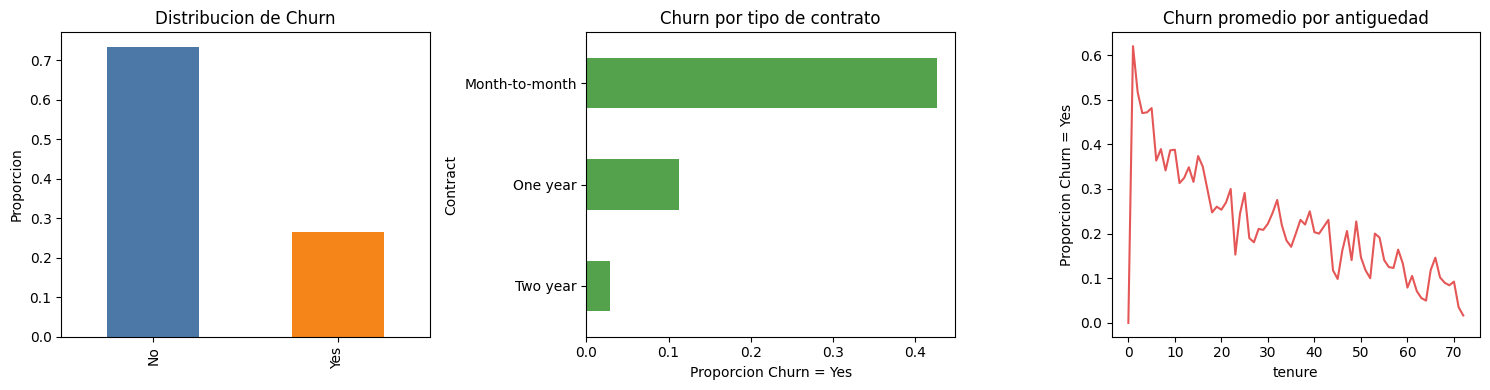

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

edf["Churn"].value_counts(normalize=True).sort_index().plot(kind="bar", ax=axes[0], color=["#4C78A8", "#F58518"])
axes[0].set_title("Distribucion de Churn")
axes[0].set_ylabel("Proporcion")
axes[0].set_xlabel("")

pd.crosstab(edf["Contract"], edf["Churn"], normalize="index")["Yes"].sort_values().plot(kind="barh", ax=axes[1], color="#54A24B")
axes[1].set_title("Churn por tipo de contrato")
axes[1].set_xlabel("Proporcion Churn = Yes")

edf.assign(churn_num=(edf["Churn"] == "Yes").astype(int)).groupby("tenure")["churn_num"].mean().plot(ax=axes[2], color="#E45756")
axes[2].set_title("Churn promedio por antiguedad")
axes[2].set_xlabel("tenure")
axes[2].set_ylabel("Proporcion Churn = Yes")

plt.tight_layout()
plt.show()

## Evaluacion

La metrica principal elegida es **F2-score** sobre la clase positiva (`Churn = Yes`).

Motivo:

- El dataset esta desbalanceado.
- En churn suele ser mas costoso no detectar a un cliente que se va que contactar a un cliente que finalmente no se iba.
- F2 prioriza el **recall** mas que la precision, pero no ignora la precision: un modelo que marque demasiados falsos positivos tambien queda penalizado.

Como metricas complementarias se reportan precision, recall, F1, ROC-AUC y matriz de confusion.

La particion de datos es:

- 80% entrenamiento.
- 20% test.
- Estratificada por `Churn`.
- `random_state = 42` para asegurar reproducibilidad.

La seleccion de modelos se realiza con validacion cruzada sobre entrenamiento usando F2. Luego, para el modelo ganador, se optimiza el umbral de decision en un subconjunto de validacion interno del entrenamiento. El test se reserva para la evaluacion final.

## Feature engineering

Se crean variables derivadas simples, interpretables y conectadas con el negocio:

- `avg_charge_per_tenure`: gasto acumulado promedio por mes de antiguedad.
- `charges_gap`: diferencia entre cargo mensual actual y gasto mensual historico estimado.
- `tenure_group`: grupo de antiguedad del cliente.
- `is_month_to_month`: indicador de contrato mensual.
- `has_fiber_optic`: indicador de fibra optica.
- `is_electronic_check`: indicador de pago con electronic check.
- `digital_payment_risk`: combinacion de facturacion electronica y electronic check.
- `support_services_count`: cantidad de servicios de soporte/proteccion contratados.
- `streaming_services_count`: cantidad de servicios de streaming contratados.
- `total_services_count`: aproximacion al nivel de vinculacion del cliente con la empresa.
- `has_support_services`: si tiene al menos un servicio de soporte/proteccion.

Estas variables se calculan antes del pipeline de modelado y se aplican igual en entrenamiento y test.

In [7]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()

    data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
    data["TotalCharges_was_missing"] = data["TotalCharges"].isna().astype(int)
    data["TotalCharges"] = data["TotalCharges"].fillna(0)

    tenure_safe = data["tenure"].replace(0, np.nan)
    data["avg_charge_per_tenure"] = (data["TotalCharges"] / tenure_safe).replace([np.inf, -np.inf], np.nan).fillna(0)
    data["charges_gap"] = data["MonthlyCharges"] - data["avg_charge_per_tenure"]
    data["tenure_is_zero"] = (data["tenure"] == 0).astype(int)

    bins = [-1, 6, 12, 24, 48, np.inf]
    labels = ["0-6", "7-12", "13-24", "25-48", "49+"]
    data["tenure_group"] = pd.cut(data["tenure"], bins=bins, labels=labels).astype("object")

    data["is_month_to_month"] = (data["Contract"] == "Month-to-month").astype(int)
    data["has_fiber_optic"] = (data["InternetService"] == "Fiber optic").astype(int)
    data["is_electronic_check"] = (data["PaymentMethod"] == "Electronic check").astype(int)
    data["paperless_billing_flag"] = (data["PaperlessBilling"] == "Yes").astype(int)
    data["digital_payment_risk"] = (data["paperless_billing_flag"] & data["is_electronic_check"]).astype(int)

    support_cols = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport"]
    streaming_cols = ["StreamingTV", "StreamingMovies"]
    service_cols = ["PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"]

    data["support_services_count"] = (data[support_cols] == "Yes").sum(axis=1)
    data["streaming_services_count"] = (data[streaming_cols] == "Yes").sum(axis=1)
    data["phone_or_addon_services_count"] = (data[service_cols] == "Yes").sum(axis=1)
    data["has_internet_service"] = (data["InternetService"] != "No").astype(int)
    data["total_services_count"] = data["phone_or_addon_services_count"] + data["has_internet_service"]
    data["has_support_services"] = (data["support_services_count"] > 0).astype(int)

    return data

model_df = build_features(df_raw)
y = (model_df["Churn"] == "Yes").astype(int)
X = model_df.drop(columns=["Churn", "customerID"])

X_train, X_test, y_train, y_test, customer_train, customer_test = train_test_split(
    X,
    y,
    model_df["customerID"],
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Churn train:", y_train.mean().round(4), "Churn test:", y_test.mean().round(4))

Train: (5634, 35) Test: (1409, 35)
Churn train: 0.2654 Churn test: 0.2654


In [8]:
numeric_features = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_transformer, numeric_features),
        ("categorical", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Variables numericas:", len(numeric_features))
print(numeric_features)
print()
print("Variables categoricas:", len(categorical_features))
print(categorical_features)

Variables numericas: 19
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'TotalCharges_was_missing', 'avg_charge_per_tenure', 'charges_gap', 'tenure_is_zero', 'is_month_to_month', 'has_fiber_optic', 'is_electronic_check', 'paperless_billing_flag', 'digital_payment_risk', 'support_services_count', 'streaming_services_count', 'phone_or_addon_services_count', 'has_internet_service', 'total_services_count', 'has_support_services']

Variables categoricas: 16
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


## Baseline y modelos candidatos

Se compara un baseline tonto contra modelos predictivos reales.

- `DummyClassifier`: predice siempre la clase mayoritaria. Sirve como piso minimo.
- `LogisticRegression`: modelo lineal interpretable.
- `DecisionTree`: arbol simple, facil de explicar pero propenso a sobreajuste.
- `RandomForest`: ensamble de arboles, suele capturar relaciones no lineales.
- `GradientBoosting`: ensamble secuencial, buen candidato para datos tabulares pequenos/medianos.

La seleccion se hace por F2 promedio en validacion cruzada estratificada de 5 folds sobre el conjunto de entrenamiento.

In [9]:
models = {
    "dummy_most_frequent": DummyClassifier(strategy="most_frequent"),
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "decision_tree": DecisionTreeClassifier(max_depth=5, min_samples_leaf=30, class_weight="balanced", random_state=RANDOM_STATE),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    "gradient_boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

scoring = {
    "f2": f2_scorer,
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []

for name, estimator in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", estimator),
    ])
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,
        return_train_score=False,
    )
    row = {"model": name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    results.append(row)

cv_results = pd.DataFrame(results).sort_values("f2_mean", ascending=False)
cv_results

,model,f2_mean,f2_std,f1_mean,f1_std,precision_mean,precision_std,recall_mean,recall_std,roc_auc_mean,roc_auc_std,accuracy_mean,accuracy_std
1,logistic_regression,0.714727,0.028826,0.626758,0.021565,0.520209,0.015786,0.788629,0.036661,0.846885,0.011857,0.750979,0.012485
2,decision_tree,0.708166,0.020846,0.623364,0.009611,0.520228,0.012178,0.779264,0.034434,0.831535,0.012817,0.750267,0.009084
3,random_forest,0.702708,0.019798,0.635017,0.016964,0.547258,0.015201,0.756522,0.023113,0.847198,0.009787,0.769261,0.010741
4,gradient_boosting,0.534693,0.032171,0.578649,0.030351,0.671562,0.034417,0.509030,0.033605,0.846366,0.012227,0.803516,0.013141
0,dummy_most_frequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.734647,0.000094


In [10]:
cv_results_display = cv_results[[
    "model", "f2_mean", "f2_std", "recall_mean", "precision_mean", "f1_mean", "roc_auc_mean", "accuracy_mean"
]].copy()
cv_results_display.to_csv(OUTPUTS_DIR / "model_selection_cv_results.csv", index=False)
cv_results_display

,model,f2_mean,f2_std,recall_mean,precision_mean,f1_mean,roc_auc_mean,accuracy_mean
1,logistic_regression,0.714727,0.028826,0.788629,0.520209,0.626758,0.846885,0.750979
2,decision_tree,0.708166,0.020846,0.779264,0.520228,0.623364,0.831535,0.750267
3,random_forest,0.702708,0.019798,0.756522,0.547258,0.635017,0.847198,0.769261
4,gradient_boosting,0.534693,0.032171,0.509030,0.671562,0.578649,0.846366,0.803516
0,dummy_most_frequent,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.734647


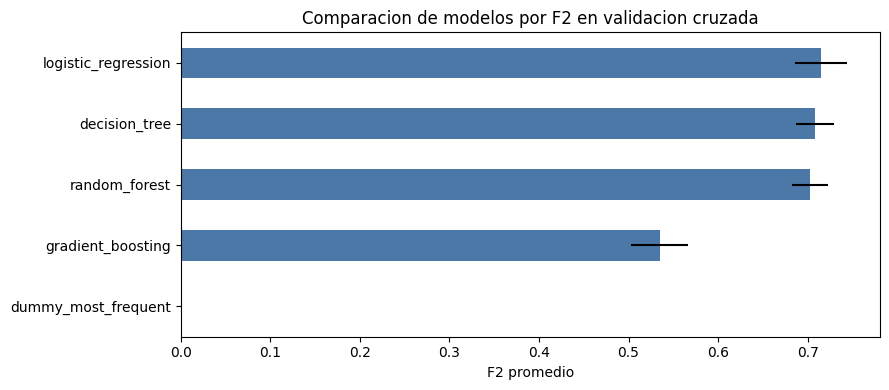

In [11]:
ax = cv_results_display.sort_values("f2_mean").plot(
    kind="barh",
    x="model",
    y="f2_mean",
    xerr="f2_std",
    figsize=(9, 4),
    legend=False,
    color="#4C78A8",
)
ax.set_title("Comparacion de modelos por F2 en validacion cruzada")
ax.set_xlabel("F2 promedio")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## Seleccion del modelo final y umbral

La seleccion automatica toma el modelo con mayor F2 promedio en validacion cruzada. Luego se busca el umbral de decision que maximiza F2 sobre una validacion interna del conjunto de entrenamiento.

Esto permite priorizar recall sin abandonar precision: si el umbral baja demasiado, el recall sube pero la precision cae, y F2 refleja ese costo.

In [12]:
best_model_name = cv_results.iloc[0]["model"]
best_estimator = models[best_model_name]

X_fit, X_val, y_fit, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE,
)

threshold_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_estimator),
])
threshold_model.fit(X_fit, y_fit)
val_proba = threshold_model.predict_proba(X_val)[:, 1]

threshold_rows = []
for threshold in np.round(np.arange(0.10, 0.91, 0.01), 2):
    val_pred = (val_proba >= threshold).astype(int)
    threshold_rows.append({
        "threshold": float(threshold),
        "f2": fbeta_score(y_val, val_pred, beta=2, zero_division=0),
        "f1": f1_score(y_val, val_pred, zero_division=0),
        "recall": recall_score(y_val, val_pred, zero_division=0),
        "precision": precision_score(y_val, val_pred, zero_division=0),
        "positive_rate_predicted": float(val_pred.mean()),
    })

threshold_results = pd.DataFrame(threshold_rows).sort_values(
    ["f2", "precision"],
    ascending=[False, False],
).reset_index(drop=True)

best_threshold = float(threshold_results.loc[0, "threshold"])
threshold_results.to_csv(OUTPUTS_DIR / "threshold_search_results.csv", index=False)

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_estimator),
])
final_model.fit(X_train, y_train)

print("Modelo final seleccionado:", best_model_name)
print("Umbral seleccionado:", best_threshold)
threshold_results.head(10)

Modelo final seleccionado: logistic_regression
Umbral seleccionado: 0.31


,threshold,f2,f1,recall,precision,positive_rate_predicted
0,0.31,0.740538,0.583153,0.903010,0.430622,0.556344
1,0.35,0.740122,0.591111,0.889632,0.442596,0.533274
2,0.34,0.738479,0.588496,0.889632,0.439669,0.536823
3,0.33,0.738385,0.586169,0.892977,0.436275,0.543035
4,0.32,0.738292,0.583878,0.896321,0.432956,0.549246
5,0.37,0.736783,0.594779,0.876254,0.450172,0.516415
6,0.25,0.736702,0.563581,0.926421,0.404971,0.606921
7,0.15,0.736630,0.538249,0.976589,0.371501,0.697427
8,0.30,0.736498,0.576923,0.903010,0.423862,0.565217
9,0.40,0.736390,0.606132,0.859532,0.468124,0.487134


## Evaluacion final en test

El test se usa una sola vez, despues de seleccionar el modelo por validacion cruzada y ajustar el umbral en validacion interna. Esto da una estimacion mas honesta del desempeno esperado sobre datos no vistos.

In [13]:
y_proba = final_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= best_threshold).astype(int)

test_metrics = {
    "selected_model": best_model_name,
    "decision_threshold": best_threshold,
    "random_state": RANDOM_STATE,
    "test_size": 0.20,
    "primary_metric": "f2_positive_class",
    "test_accuracy": accuracy_score(y_test, y_pred),
    "test_precision": precision_score(y_test, y_pred, zero_division=0),
    "test_recall": recall_score(y_test, y_pred, zero_division=0),
    "test_f1": f1_score(y_test, y_pred, zero_division=0),
    "test_f2": fbeta_score(y_test, y_pred, beta=2, zero_division=0),
    "test_roc_auc": roc_auc_score(y_test, y_proba),
    "train_rows": int(X_train.shape[0]),
    "test_rows": int(X_test.shape[0]),
    "positive_rate_train": float(y_train.mean()),
    "positive_rate_test": float(y_test.mean()),
    "positive_rate_predicted_test": float(y_pred.mean()),
}

pd.DataFrame([test_metrics]).T.rename(columns={0: "valor"})

,valor
selected_model,logistic_regression
decision_threshold,0.31
random_state,42
test_size,0.2
primary_metric,f2_positive_class
test_accuracy,0.662881
test_precision,0.435832
test_recall,0.917112
test_f1,0.59087
test_f2,0.751205


In [14]:
print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))

              precision    recall  f1-score   support

    No Churn       0.95      0.57      0.71      1035
       Churn       0.44      0.92      0.59       374

    accuracy                           0.66      1409
   macro avg       0.69      0.74      0.65      1409
weighted avg       0.81      0.66      0.68      1409



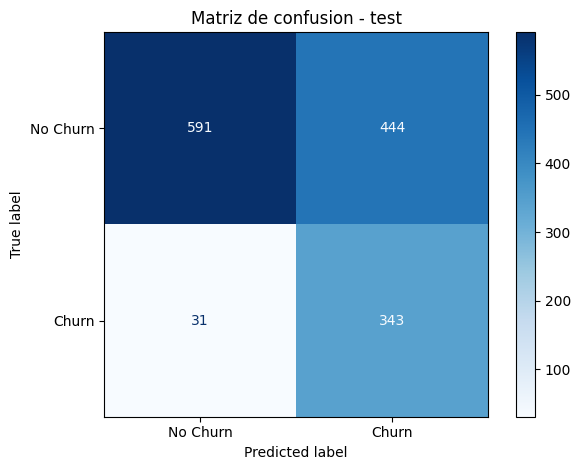

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["No Churn", "Churn"],
    cmap="Blues",
    values_format="d",
)
plt.title("Matriz de confusion - test")
plt.tight_layout()
plt.show()

## Chequeos de leakage y overfitting

Antes de interpretar el modelo se realizan controles metodologicos:

- `customerID` se excluye del entrenamiento.
- El split es estratificado y no hay clientes repetidos entre train y test.
- El preprocesamiento que aprende parametros (`SimpleImputer`, `StandardScaler`, `OneHotEncoder`) esta dentro de un `Pipeline`, por lo que se ajusta solamente con entrenamiento.
- El umbral se elige sobre una validacion interna del entrenamiento, no sobre test.
- Se comparan metricas de train contra test para detectar sobreajuste.
- Se revisan perfiles duplicados entre train y test. Si existen, se reportan como posible fuente menor de optimismo, aunque no implican leakage de identidad porque son clientes distintos y el modelo no usa `customerID`.

In [16]:
def evaluate_with_threshold(model, X_data, y_data, threshold):
    proba = model.predict_proba(X_data)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_data, pred),
        "precision": precision_score(y_data, pred, zero_division=0),
        "recall": recall_score(y_data, pred, zero_division=0),
        "f1": f1_score(y_data, pred, zero_division=0),
        "f2": fbeta_score(y_data, pred, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_data, proba),
        "predicted_positive_rate": float(pred.mean()),
    }

train_audit_metrics = evaluate_with_threshold(final_model, X_train, y_train, best_threshold)
test_audit_metrics = evaluate_with_threshold(final_model, X_test, y_test, best_threshold)

feature_hash_train = pd.util.hash_pandas_object(X_train.reset_index(drop=True), index=False)
feature_hash_test = pd.util.hash_pandas_object(X_test.reset_index(drop=True), index=False)
overlap_hashes = set(feature_hash_train).intersection(set(feature_hash_test))

train_profiles = X_train.copy()
train_profiles["split"] = "train"
train_profiles["target"] = y_train.values
train_profiles["customerID"] = customer_train.values

test_profiles = X_test.copy()
test_profiles["split"] = "test"
test_profiles["target"] = y_test.values
test_profiles["customerID"] = customer_test.values

combined_profiles = pd.concat([train_profiles, test_profiles], ignore_index=True)
feature_columns_for_hash = X_train.columns.tolist()
combined_profiles["feature_hash"] = pd.util.hash_pandas_object(combined_profiles[feature_columns_for_hash], index=False).astype(str)
profile_summary = combined_profiles.groupby("feature_hash").agg(
    rows=("customerID", "size"),
    train_rows=("split", lambda s: int((s == "train").sum())),
    test_rows=("split", lambda s: int((s == "test").sum())),
    targets=("target", lambda s: tuple(sorted(set(s)))),
).reset_index()

cross_split_duplicates = profile_summary[
    (profile_summary["train_rows"] > 0) & (profile_summary["test_rows"] > 0)
].copy()
cross_split_duplicates["same_target_only"] = cross_split_duplicates["targets"].apply(lambda values: len(values) == 1)

leakage_overfit_checks = {
    "customer_id_used_as_feature": "customerID" in X_train.columns,
    "train_test_customer_id_overlap": len(set(customer_train).intersection(set(customer_test))),
    "target_like_feature_columns": [col for col in X_train.columns if "churn" in col.lower() or col.lower() in ["target", "label", "y"]],
    "preprocessing_inside_pipeline": isinstance(final_model, Pipeline),
    "threshold_selected_on_test": False,
    "decision_threshold": best_threshold,
    "train_metrics": train_audit_metrics,
    "test_metrics": test_audit_metrics,
    "train_minus_test_f2": train_audit_metrics["f2"] - test_audit_metrics["f2"],
    "train_minus_test_roc_auc": train_audit_metrics["roc_auc"] - test_audit_metrics["roc_auc"],
    "cross_split_duplicate_feature_groups": int(len(cross_split_duplicates)),
    "cross_split_duplicate_feature_rows": int(combined_profiles["feature_hash"].isin(cross_split_duplicates["feature_hash"]).sum()),
    "cross_split_duplicate_groups_same_target_only": int(cross_split_duplicates["same_target_only"].sum()),
    "cross_split_duplicate_groups_mixed_target": int((~cross_split_duplicates["same_target_only"]).sum()),
}

with (OUTPUTS_DIR / "leakage_overfit_checks.json").open("w", encoding="utf-8") as f:
    json.dump(leakage_overfit_checks, f, indent=2)

pd.DataFrame({
    "train": train_audit_metrics,
    "test": test_audit_metrics,
    "train_minus_test": {
        key: train_audit_metrics[key] - test_audit_metrics[key]
        for key in train_audit_metrics
    },
}).round(4)

,train,test,train_minus_test
accuracy,0.6603,0.6629,-0.0026
precision,0.4337,0.4358,-0.0022
recall,0.9164,0.9171,-0.0007
f1,0.5887,0.5909,-0.0021
f2,0.7495,0.7512,-0.0017
roc_auc,0.8526,0.8446,0.0080
predicted_positive_rate,0.5607,0.5586,0.0022


Lectura del control:

- No se detectan columnas objetivo ni identificadores dentro de las variables predictoras.
- La diferencia entre train y test es baja, por lo que no hay senal fuerte de overfitting.
- Existen algunos perfiles de clientes repetidos entre train y test, pero son clientes distintos y varios tienen targets diferentes. Esto no constituye leakage directo; se reporta como una limitacion menor del split aleatorio sobre un dataset con perfiles discretos.

## Interpretacion del modelo final: feature importance y SHAP

Como el modelo final seleccionado es una regresion logistica, la interpretacion principal se hace con los coeficientes del modelo luego del preprocesamiento. Como las variables numericas fueron estandarizadas y las categoricas codificadas con one-hot encoding, los coeficientes permiten identificar que variables empujan la prediccion hacia mayor o menor probabilidad de churn.

Ademas se calculan dos lecturas complementarias:

- **Permutation importance** usando F2: mide cuanto cae la metrica si se desordena una variable original.
- **SHAP values**: descompone el score del modelo en aportes por variable transformada.

Estas importancias explican comportamiento predictivo del modelo; no deben interpretarse como causalidad.

In [17]:
from sklearn.inspection import permutation_importance
import shap

def clean_feature_name(name: str) -> str:
    return (
        name
        .replace("numeric__", "")
        .replace("categorical__", "")
    )

def get_feature_names(fitted_pipeline):
    pre = fitted_pipeline.named_steps["preprocessor"]
    return pre.get_feature_names_out()

feature_names = get_feature_names(final_model)
clean_feature_names = [clean_feature_name(name) for name in feature_names]
model_step = final_model.named_steps["model"]

coef_importance = pd.DataFrame({
    "feature": clean_feature_names,
    "raw_feature": feature_names,
    "coefficient": model_step.coef_[0],
})
coef_importance["abs_importance"] = coef_importance["coefficient"].abs()
coef_importance["direction"] = np.where(coef_importance["coefficient"] >= 0, "Aumenta churn", "Reduce churn")
coef_importance = coef_importance.sort_values("abs_importance", ascending=False)
coef_importance.to_csv(OUTPUTS_DIR / "feature_importance_coefficients.csv", index=False)

# Se mantiene este nombre historico para compatibilidad con README/outputs previos.
importance = coef_importance.rename(columns={"coefficient": "importance"}).copy()
importance.to_csv(OUTPUTS_DIR / "feature_importance.csv", index=False)

coef_importance.head(20)

,feature,raw_feature,coefficient,abs_importance,direction
9,has_fiber_optic,numeric__has_fiber_optic,0.687019,0.687019,Aumenta churn
1,tenure,numeric__tenure,-0.618712,0.618712,Reduce churn
2,MonthlyCharges,numeric__MonthlyCharges,-0.618475,0.618475,Reduce churn
5,avg_charge_per_tenure,numeric__avg_charge_per_tenure,-0.607063,0.607063,Reduce churn
53,Contract_Two year,categorical__Contract_Two year,-0.589679,0.589679,Reduce churn
60,tenure_group_0-6,categorical__tenure_group_0-6,0.508780,0.508780,Aumenta churn
8,is_month_to_month,numeric__is_month_to_month,0.448559,0.448559,Aumenta churn
16,has_internet_service,numeric__has_internet_service,0.315402,0.315402,Aumenta churn
52,Contract_One year,categorical__Contract_One year,0.302298,0.302298,Aumenta churn
14,streaming_services_count,numeric__streaming_services_count,0.295946,0.295946,Aumenta churn


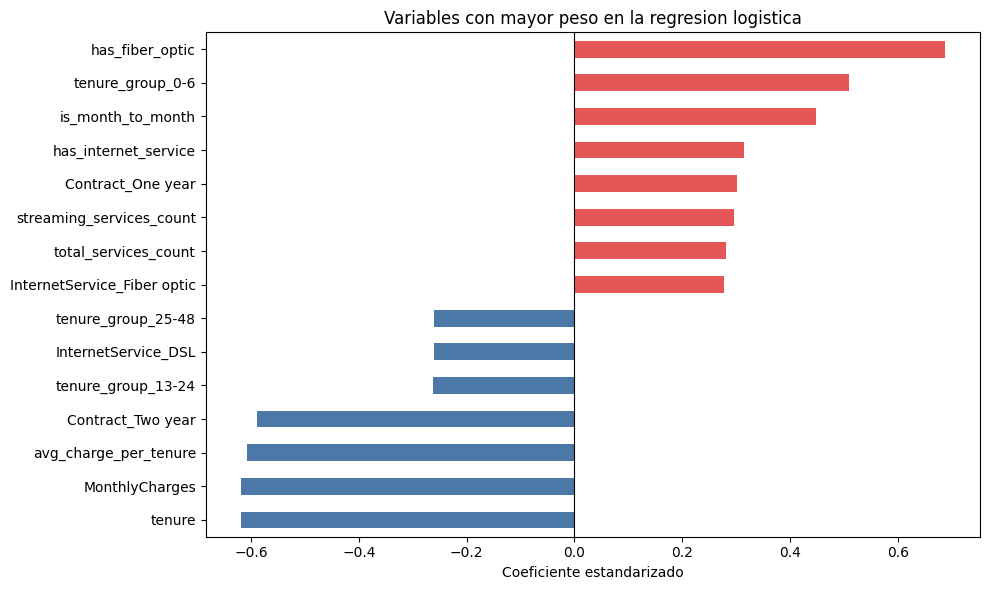

In [18]:
top_coef = coef_importance.head(15).sort_values("coefficient")
colors = np.where(top_coef["coefficient"] >= 0, "#E45756", "#4C78A8")

ax = top_coef.plot(
    kind="barh",
    x="feature",
    y="coefficient",
    figsize=(10, 6),
    legend=False,
    color=colors,
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Variables con mayor peso en la regresion logistica")
ax.set_xlabel("Coeficiente estandarizado")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "feature_importance_coefficients.png", dpi=160, bbox_inches="tight")
plt.show()

### Permutation importance sobre variables originales

La permutation importance se calcula sobre el pipeline completo y sobre las columnas originales/derivadas antes del one-hot encoding. Esto ayuda a explicar el modelo a nivel de variables de negocio, no a nivel de cada dummy.

In [19]:
f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)
perm = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring=f2_scorer,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

permutation_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)

permutation_importance_df.to_csv(OUTPUTS_DIR / "feature_importance_permutation_f2.csv", index=False)
permutation_importance_df.head(20)

,feature,importance_mean,importance_std
25,has_fiber_optic,0.070225,0.010880
4,tenure,0.068228,0.009201
24,is_month_to_month,0.050223,0.010550
17,MonthlyCharges,0.031488,0.011024
20,avg_charge_per_tenure,0.029928,0.009805
23,tenure_group,0.023273,0.005656
14,Contract,0.019032,0.008913
32,has_internet_service,0.012166,0.010796
34,has_support_services,0.005940,0.003363
7,InternetService,0.005570,0.005148


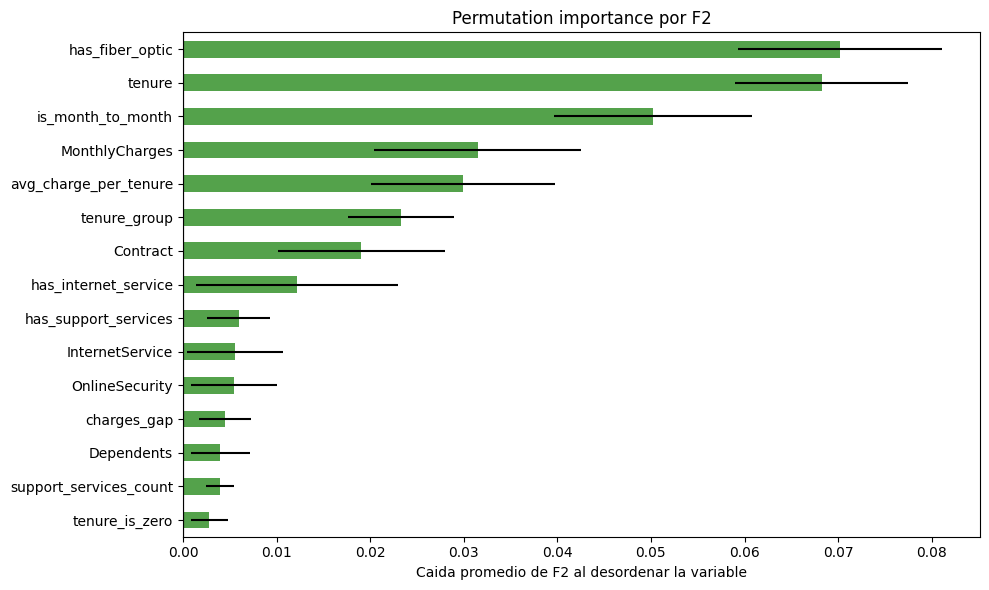

In [20]:
top_perm = permutation_importance_df.head(15).sort_values("importance_mean")
ax = top_perm.plot(
    kind="barh",
    x="feature",
    y="importance_mean",
    xerr="importance_std",
    figsize=(10, 6),
    legend=False,
    color="#54A24B",
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Permutation importance por F2")
ax.set_xlabel("Caida promedio de F2 al desordenar la variable")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "feature_importance_permutation_f2.png", dpi=160, bbox_inches="tight")
plt.show()

### SHAP values

Para SHAP se transforma el test con el preprocesador ya ajustado y se explican los aportes de la regresion logistica. Se reporta la importancia media absoluta de SHAP, que resume cuanto aporta cada variable transformada al score del modelo.

In [21]:
X_test_transformed = final_model.named_steps["preprocessor"].transform(X_test)
if not isinstance(X_test_transformed, np.ndarray):
    X_test_transformed = X_test_transformed.toarray()

# Muestra acotada para que la notebook siga siendo rapida y reproducible.
shap_sample_size = min(1000, X_test_transformed.shape[0])
X_shap = X_test_transformed[:shap_sample_size]

explainer = shap.LinearExplainer(model_step, X_shap)
shap_values = explainer(X_shap)
shap_array = shap_values.values

shap_importance = pd.DataFrame({
    "feature": clean_feature_names,
    "mean_abs_shap": np.abs(shap_array).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.to_csv(OUTPUTS_DIR / "feature_importance_shap.csv", index=False)
shap_importance.head(20)

,feature,mean_abs_shap
9,has_fiber_optic,0.696051
1,tenure,0.542951
2,MonthlyCharges,0.530256
5,avg_charge_per_tenure,0.522003
8,is_month_to_month,0.441783
16,has_internet_service,0.268429
14,streaming_services_count,0.264616
17,total_services_count,0.231429
15,phone_or_addon_services_count,0.209817
53,Contract_Two year,0.199311


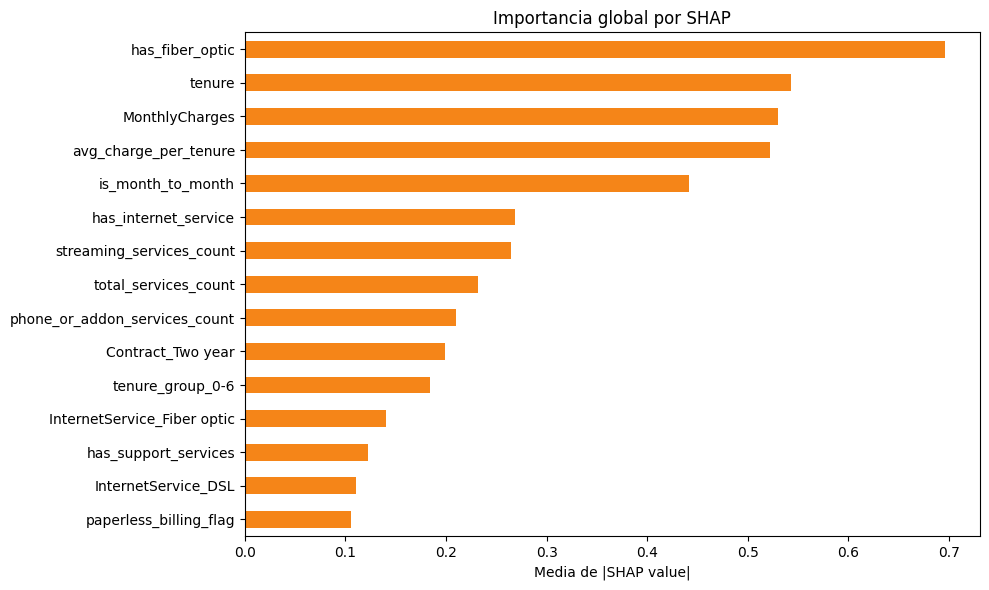

In [22]:
top_shap = shap_importance.head(15).sort_values("mean_abs_shap")
ax = top_shap.plot(
    kind="barh",
    x="feature",
    y="mean_abs_shap",
    figsize=(10, 6),
    legend=False,
    color="#F58518",
)
ax.set_title("Importancia global por SHAP")
ax.set_xlabel("Media de |SHAP value|")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "feature_importance_shap.png", dpi=160, bbox_inches="tight")
plt.show()

## Guardado de artefactos

La consigna pide que la notebook entrene y guarde el modelo final. Se exportan:

- `models/final_model.joblib`: pipeline final entrenado.
- `outputs/model_metrics.json`: metricas finales, umbral seleccionado y configuracion del split.
- `outputs/model_selection_cv_results.csv`: resultados de seleccion por validacion cruzada.
- `outputs/threshold_search_results.csv`: evaluacion de umbrales por F2 en validacion interna.
- `outputs/test_predictions.csv`: predicciones del modelo final sobre el test interno.
- `outputs/feature_importance.csv`: coeficientes principales del modelo final.
- `outputs/feature_importance_coefficients.csv`: coeficientes detallados.
- `outputs/feature_importance_permutation_f2.csv`: permutation importance por F2.
- `outputs/feature_importance_shap.csv`: importancia global por SHAP.
- `outputs/*.png`: graficos de interpretabilidad para la presentacion.

In [23]:
model_path = MODELS_DIR / "final_model.joblib"
metrics_path = OUTPUTS_DIR / "model_metrics.json"
predictions_path = OUTPUTS_DIR / "test_predictions.csv"
importance_path = OUTPUTS_DIR / "feature_importance.csv"

joblib.dump(final_model, model_path)

with metrics_path.open("w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)

predictions = pd.DataFrame({
    "customerID": customer_test.values,
    "y_true": y_test.values,
    "churn_probability": y_proba,
    "decision_threshold": best_threshold,
    "churn_prediction": y_pred,
})
predictions["y_true_label"] = predictions["y_true"].map({0: "No", 1: "Yes"})
predictions["churn_prediction_label"] = predictions["churn_prediction"].map({0: "No", 1: "Yes"})
predictions.to_csv(predictions_path, index=False)
importance.to_csv(importance_path, index=False)

print("Modelo guardado en:", model_path)
print("Metricas guardadas en:", metrics_path)
print("Predicciones guardadas en:", predictions_path)
print("Importancias guardadas en:", importance_path)

Modelo guardado en: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final\models\final_model.joblib
Metricas guardadas en: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final\outputs\model_metrics.json
Predicciones guardadas en: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final\outputs\test_predictions.csv
Importancias guardadas en: C:\Users\matut\OneDrive\Escritorio\Tp 1 Predictivo\Telco-Churn-Examen-Final\outputs\feature_importance.csv


## Limitaciones y posibles mejoras

Limitaciones principales:

- El dataset es una foto historica; no incluye comportamiento temporal detallado ni interacciones recientes del cliente.
- La evaluacion se realiza con una particion interna porque no hay un test externo provisto en el repositorio.
- Las asociaciones encontradas no deben interpretarse como causalidad.
- El umbral de decision fue optimizado por F2 en una validacion interna; con mas informacion de negocio podria ajustarse usando costos reales de falsos positivos y falsos negativos.

Posibles mejoras:

- Incorporar datos de reclamos, contactos con soporte, historial de promociones y cambios de plan.
- Ajustar el umbral de decision segun una matriz de costos de negocio.
- Validar el modelo con datos de otro periodo para medir estabilidad temporal.
- Probar calibracion de probabilidades si la empresa usara el score para priorizar acciones comerciales.

## Conclusiones

El proyecto convierte el caso de churn en un flujo predictivo reproducible. Se define una metrica adecuada para un problema desbalanceado y orientada a recall, se construyen variables derivadas interpretables, se compara un baseline contra modelos candidatos y se guarda un modelo final aplicable a datos nuevos.

La utilidad de negocio esta en transformar los datos historicos en un ranking de clientes con mayor riesgo de baja, permitiendo priorizar acciones de retencion de forma mas informada.